In [54]:
import torch
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,TensorDataset #do koncowego przygotowania danych
import pysam
import yfinance as yf #do danych finansowych

from sklearn.preprocessing import MinMaxScaler #do skalowania

from sklearn.metrics import classification_report #do robienia raportów o uczeniu

import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.api as sm

import optuna
from optuna.trial import TrialState

import copy
import json 

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [2]:
import torch
import numpy as np
import random
import os

def set_seed(seed=612):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(612) 



In [3]:
dane=np.load('dane.npz')
X=dane['X']
Y=dane['Y']

print(X.shape,Y.shape)

(4061, 24) (4061,)


In [4]:

X_tensor=torch.tensor(X,dtype=torch.float32).to(device)
Y_tensor=torch.tensor(Y,dtype=torch.float32).unsqueeze(1).to(device)


split_point = int(0.8 * len(Y_tensor))


X_train = X_tensor[:split_point]
y_train = Y_tensor[:split_point]


X_test = X_tensor[split_point: ]
y_test = Y_tensor[split_point: ]

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [5]:
class trader(nn.Module):
    def __init__(self,input_dim,dim_1,dim_2,dropout):
        super().__init__()
        self.input_dim=input_dim
        self.dim_1=dim_1
        self.dim_2=dim_2
        self.dropout=dropout

        self.network = nn.Sequential(

            nn.Linear(input_dim, dim_1),
            nn.BatchNorm1d(dim_1),       
            nn.ReLU(),
            nn.Dropout(dropout),          
            
            nn.Linear(dim_1, dim_2),
            nn.BatchNorm1d(dim_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(dim_2, 1),         
            nn.Sigmoid()              
        )
        
    def forward(self, x):
        return self.network(x)



In [51]:
def objective(trial):

    dim_1 = trial.suggest_int('dim_1', 32, 256) 
    dim_2 = trial.suggest_int('dim_2', 16, 128) 
    dropout = trial.suggest_float('dropout', 0.1, 0.6) 
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True) 
    decay = trial.suggest_float('weight_decay', 0, 1e-1, log=False)


    input_dim = X.shape[1] 
    model = trader(input_dim, dim_1, dim_2, dropout).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)
    criterion = nn.BCELoss()
    

    SEARCH_EPOCHS = 30 
    
    for epoch in range(SEARCH_EPOCHS):

        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x_test, y_test in test_loader:
                x_test, y_test = x_test.to(device), y_test.to(device)
                test_preds = model(x_test)
                pred_cls = (test_preds > 0.5).float()
                correct += (pred_cls == y_test).sum().item()
                total += y_test.size(0)
        
        accuracy = correct / total


        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()


    return accuracy

study = optuna.create_study(direction='maximize') 


study.optimize(objective, n_trials=100)



for key, value in study.best_params.items():
    print(f"  {key}: {value}")



best_params = study.best_params



[I 2026-01-04 19:02:11,718] A new study created in memory with name: no-name-09f05a59-5c94-47a3-85c1-5ff334a1ca28
[I 2026-01-04 19:02:18,343] Trial 0 finished with value: 0.5190651906519065 and parameters: {'dim_1': 244, 'dim_2': 32, 'dropout': 0.1468886727702273, 'lr': 0.0010569359698602275, 'weight_decay': 0.059007580147230655}. Best is trial 0 with value: 0.5190651906519065.
[I 2026-01-04 19:02:24,986] Trial 1 finished with value: 0.5227552275522755 and parameters: {'dim_1': 188, 'dim_2': 71, 'dropout': 0.5829990817159, 'lr': 0.00018176723619800148, 'weight_decay': 0.06719932021733692}. Best is trial 1 with value: 0.5227552275522755.
[I 2026-01-04 19:02:32,408] Trial 2 finished with value: 0.5190651906519065 and parameters: {'dim_1': 38, 'dim_2': 121, 'dropout': 0.5612896751266716, 'lr': 0.006743604462050619, 'weight_decay': 0.06270192935068049}. Best is trial 1 with value: 0.5227552275522755.
[I 2026-01-04 19:02:39,019] Trial 3 finished with value: 0.5227552275522755 and parameters

  dim_1: 254
  dim_2: 74
  dropout: 0.35311900127142437
  lr: 6.266428744353899e-05
  weight_decay: 0.09524787353607977


In [42]:

#dim_1=best_params['dim_1']=64
#dim_2=best_params['dim_2']=32
#dropout=best_params['dropout']=0.4
#lr=best_params['lr']=1e-3
#weight_decay=best_params['weight_decay']=0
print(best_params)

{'dim_1': 64, 'dim_2': 32, 'dropout': 0.4, 'lr': 0.001, 'weight_decay': 0}


Rozpoczynam trening na 3248 próbkach...
Epoka   0 | Loss: 0.7107 | Test Loss: 0.6954| Train Acc: 51.3% | Test Acc: 49.3%
Epoka  10 | Loss: 0.6991 | Test Loss: 0.6924| Train Acc: 51.7% | Test Acc: 52.4%
Epoka  20 | Loss: 0.6924 | Test Loss: 0.6929| Train Acc: 52.7% | Test Acc: 52.5%
Epoka  30 | Loss: 0.6867 | Test Loss: 0.6920| Train Acc: 54.9% | Test Acc: 54.4%
Epoka  40 | Loss: 0.6869 | Test Loss: 0.6923| Train Acc: 55.1% | Test Acc: 52.9%


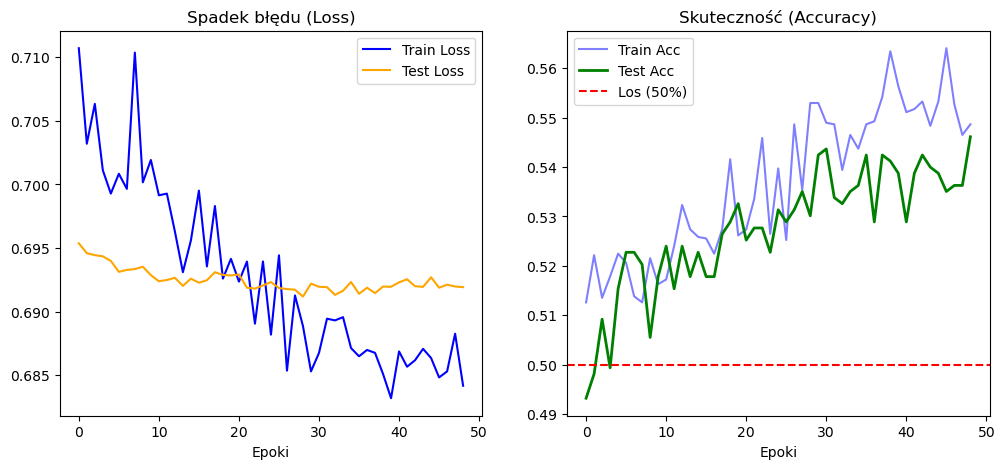

Finalna skuteczność na teście: 54.61%


In [52]:


model=trader(input_dim=X.shape[1],dim_1=best_params['dim_1'],dim_2=best_params['dim_2'],dropout=best_params['dropout'])
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
criterion = nn.BCELoss()

EPOCHS = 49
loss_history = []
val_loss_history = []
acc_history_train = []
acc_history_test = []

print(f"Rozpoczynam trening na {len(X_train)} próbkach...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    correct_train = 0
    total_train = 0
   
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        predicted_classes = (predictions > 0.5).float()
        correct_train += (predicted_classes == y_batch).sum().item()
        total_train += y_batch.size(0)

    model.eval()
    correct_test = 0
    total_test = 0
    test_epoch_loss = 0
    
    with torch.no_grad():
        for x_test_batch, y_test_batch in test_loader:
            x_test_batch = x_test_batch.to(device)
            y_test_batch = y_test_batch.to(device)
            
            test_preds = model(x_test_batch)

            loss_test = criterion(test_preds, y_test_batch)
            test_epoch_loss += loss_test.item()

            pred_cls = (test_preds > 0.5).float()
            
            correct_test += (pred_cls == y_test_batch).sum().item()
            total_test += y_test_batch.size(0)

    avg_loss = epoch_loss / len(train_loader)
    avg_test_loss = test_epoch_loss / len(test_loader)
    acc_train = correct_train / total_train
    acc_test = correct_test / total_test
    
    loss_history.append(avg_loss)
    val_loss_history.append(avg_test_loss)
    acc_history_train.append(acc_train)
    acc_history_test.append(acc_test)
    
    if epoch % 10 == 0:
        print(f"Epoka {epoch:3d} | Loss: {avg_loss:.4f} | Test Loss: {avg_test_loss:.4f}| Train Acc: {acc_train*100:.1f}% | Test Acc: {acc_test*100:.1f}%")


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Test Loss', color='orange')
plt.title('Spadek błędu (Loss)')
plt.xlabel('Epoki')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(acc_history_train, label='Train Acc', color='blue', alpha=0.5)
plt.plot(acc_history_test, label='Test Acc', color='green', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Los (50%)')
plt.title('Skuteczność (Accuracy)')
plt.xlabel('Epoki')
plt.legend()

plt.show()

print(f"Finalna skuteczność na teście: {acc_history_test[-1]*100:.2f}%")

In [55]:

#torch.save(model.state_dict(), "model_1_acc_54.61%.pt")
#config_to_save = study.best_params.copy()
#config_to_save['input_dim'] = X.shape[1] 
#config_to_save['best_accuracy'] = study.best_value

#with open('best_model_config.json', 'w') as f:
#    json.dump(config_to_save, f, indent=4)